# Tests

In [14]:
%load_ext autoreload
%autoreload 2

In [15]:
!pip install -e src/ &>/dev/null

In [16]:
import cupy as cp
import numpy as np

from src.channels import AWGNChannel, BECChannel
from src.core import PolarCode, PolarEncoder, awgn_frozen_set, bec_frozen_set, sc_decode, sc_decode_llr, bp_decode, bpl_decode, scl_decode
from src.core.crc.crc import CRC

In [50]:
Ns = [256]
Ks = [139]
channels: list[str] = ["BEC", "AWGN"]

In [51]:
import json
import os
from datetime import datetime

all_runs: list = []  #*one entry per (N, K) iteration, consumed by the plotting cells below

for N, K in zip(Ns, Ks):
    print("N:", N, "- K:", K)

    CHANNEL: str = "AWGN" #*"BEC" or "AWGN"
    CHANNEL_CONFIGS = {
        #*at eps <= 0.2 every decoder scores 100% and the histograms collapse
        "BEC": {"param": 0.40, "cls": BECChannel, "frozen_set": bec_frozen_set, "param_name": "epsilon"},
        #*at param <= 3.0, all decoders fail completely, while at 7 seems like they succeed
        "AWGN": {"param": 5.0, "cls": AWGNChannel, "frozen_set": awgn_frozen_set, "param_name": "Es/N0 (dB)"}, #*(higher = better)
    }
    config = CHANNEL_CONFIGS[CHANNEL]
    CHANNEL_PARAM: float = config["param"]

    ITERATIONS: int = 75 #*number of experiments, i.e. of points in each distribution
    SAMPLES: int = 50 #*random us drawn per experiment (2**K cannot be enumerated at K=64)
    ITER_CAP: int = 40 #*BP/BPL converge quickly or never, so a bigger cap only costs time
    N_GRAPHS: int = 24 #*BPL's list size L, capped at log2(N)! = 5040 here
    L_SCL: int = 8 #*SCL list size
    SEED: int = 0 #*see the np.random.seed call below the decoders
    verbose: int = 0

    frozen_set = config["frozen_set"](N, K, CHANNEL_PARAM)
    encoder = PolarEncoder(PolarCode(N, K, frozen_set))
    channel = config["cls"](CHANNEL_PARAM)

    CRC_TYPE: str = "CRC11"
    crc = CRC(CRC_TYPE, K=K) #*the K info bits are M message bits followed by crc.R check bits
    M: int = K - crc.R #*actual payload length carried under CA-BPL; the rest is CRC.encode()'s tail
    print(f"{CHANNEL} channel, {config['param_name']} = {CHANNEL_PARAM}, N = {N}, K = {K}, "
        f"M = {M} ({CRC_TYPE}, R = {crc.R})")


    #*use_gpu below is set per decoder from measured cost at this N, not by preference:
    #*BPL/CA-BPL sweep (L, N, log2(N)+1) tensors in a handful of big kernels and run
    #*25-33x faster on the GPU, while SCL walks the N bits one at a time on small
    #*arrays, so launch overhead dominates and it is ~14x slower there. SC and BP have
    #*no GPU path at all (bp_decode always allocates R/L with np.zeros).
    def _sc(llrs: np.ndarray, u: np.ndarray) -> bool:
        raw_estimate = sc_decode_llr(frozen_set, llrs)
        clean_estimate = np.array([int(raw_estimate[i]) for i in range(raw_estimate.size) if i not in frozen_set])
        return np.array_equal(u, clean_estimate)


    def _scl(llrs: np.ndarray, u: np.ndarray) -> bool:
        estimate, _ = scl_decode(frozen_set, llrs, L=L_SCL, use_gpu=False)
        return np.array_equal(u, estimate)


    def _bp(llrs: np.ndarray, u: np.ndarray) -> bool:
        estimate, successful = bp_decode(frozen_set, llrs, None, ITER_CAP, parallel=True)
        return successful and np.array_equal(u, estimate)


    def _bpl(llrs: np.ndarray, u: np.ndarray) -> bool:
        #!We must confirm at which N this is not the case
        estimate, successful = bpl_decode(frozen_set, llrs, N_GRAPHS, ITER_CAP, use_gpu=True)
        return successful and np.array_equal(u, estimate)


    def _ca_bpl(llrs: np.ndarray, u: np.ndarray) -> bool:
        #*CA-BPL only vouches for the M message bits; u's last crc.R bits are the CRC's
        #*own check bits (appended at encode time below), not part of the payload
        estimate, successful = bpl_decode(frozen_set, llrs, N_GRAPHS, ITER_CAP, ca=True, crc=crc, use_gpu=True)
        return successful and np.array_equal(u[:M], estimate)

    decoders = {"SC": _sc, "SCL": _scl, "BP": _bp, "BPL": _bpl, "CA-BPL": _ca_bpl}
    results = {name: {"right_counts": [], "perfect_count": 0} for name in decoders}

    #*Every random draw in the run -- the payloads here, the channel's erasures/noise, and
    #*the stage permutations bpl_decode picks per call -- comes off numpy's global stream,
    #*so this one seed pins the whole experiment. Caveat: they all *share* that stream, so
    #*editing `decoders` (or any decoder's call count) shifts every draw that follows it.
    #*Runs are reproducible for a fixed decoder set, not comparable across different ones.
    np.random.seed(SEED)
    cp.random.seed(SEED)

    for i in range(ITERATIONS):
        print("iter", i)
        per_it_right_counts = {name: 0 for name in decoders}
        #*Resample at every iteration
        for samp in range(SAMPLES):
            u_msg = np.random.randint(0, 2, size=M).astype(np.uint8) #*actual payload
            u = np.array(crc.encode(u_msg), dtype=np.uint8) #*payload + CRC bits, this is what gets polar-encoded
            llrs = channel.transmit(encoder.encode(u))
            for name, decode in decoders.items():
                right = decode(llrs, u)
                per_it_right_counts[name] += right
                if verbose >= 2:
                    print(f"[{name}] Is {u} correctly decoded?", right)
            print(samp, end="-")

        for name in decoders:
            right_count = per_it_right_counts[name]
            if verbose >= 1:
                print(f"[{name}] {right_count} out of {SAMPLES} were correctly decoded")
            results[name]["right_counts"].append(right_count)
            if right_count == SAMPLES:
                results[name]["perfect_count"] += 1

    #*built as a list (rather than printed straight away) so the plotting cell can
    #*save this exact text alongside the figure it produces
    summary_lines = [f"{CHANNEL} ({config['param_name']} = {CHANNEL_PARAM}), N = {N}, K = {K}, "
                    f"L_SCL = {L_SCL}, L_BPL = {N_GRAPHS}, iter_cap = {ITER_CAP}, seed = {SEED}"]
    for name in decoders:
        perfect_count = results[name]["perfect_count"]
        total_right = sum(results[name]["right_counts"])
        percentage = (perfect_count / ITERATIONS) * 100
        summary_lines.append(f"{name}: {perfect_count} / {ITERATIONS} perfect runs ({percentage:.2f} %), "
                            f"{total_right} / {ITERATIONS * SAMPLES} words decoded ({total_right / (ITERATIONS * SAMPLES) * 100:.2f} %)")
    print("\n" + "\n".join(summary_lines))

    #*persist the raw per-decoder distributions (not just the printed summary) so
    #*different runs/configs can be compared programmatically later; run_tag is reused
    #*by the plotting cells below so a run's .json/.png/.txt all share the same name
    run_tag = f"{CHANNEL}_N{N}_K{K}_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
    RESULTS_DIR = "results"
    os.makedirs(RESULTS_DIR, exist_ok=True)

    #*cast to plain int: right_count accumulates via `+=` on decoder bool results, which
    #*can end up as numpy scalar types that json.dump rejects
    run_data = {name: {"right_counts": [int(c) for c in r["right_counts"]],
                        "perfect_count": int(r["perfect_count"])}
                for name, r in results.items()}

    with open(os.path.join(RESULTS_DIR, f"{run_tag}.json"), "w") as f:
        json.dump({
            "run_tag": run_tag, "channel": CHANNEL, "channel_param": CHANNEL_PARAM,
            "N": N, "K": K, "M": M, "iterations": ITERATIONS, "samples": SAMPLES,
            "iter_cap": ITER_CAP, "n_graphs": N_GRAPHS, "l_scl": L_SCL,
            "seed": SEED, "crc_type": CRC_TYPE, "results": run_data,
        }, f, indent=2)
    print(f"Saved raw distribution data to {RESULTS_DIR}/{run_tag}.json")

    all_runs.append({"run_tag": run_tag, "CHANNEL": CHANNEL, "config": config, "N": N, "K": K,
                      "N_GRAPHS": N_GRAPHS, "SAMPLES": SAMPLES, "results": results,
                      "summary_lines": summary_lines})

N: 256 - K: 139
AWGN channel, Es/N0 (dB) = 5.0, N = 256, K = 139, M = 128 (CRC11, R = 11)
iter 0
0-1-2-3-4-5-6-7-8-9-10-11-12-13-14-15-16-17-18-19-20-21-22-23-24-25-26-27-28-29-30-31-32-33-34-35-36-37-38-39-40-41-42-43-44-45-46-47-48-49-iter 1
0-1-2-3-4-5-6-7-8-9-10-11-12-13-14-15-16-17-18-19-20-21-22-23-24-25-26-27-28-29-30-31-32-33-34-35-36-37-38-39-40-41-42-43-44-45-46-47-48-49-iter 2
0-1-2-3-4-5-6-7-8-9-10-11-12-13-14-15-16-17-18-19-20-21-22-23-24-25-26-27-28-29-30-31-32-33-34-35-36-37-38-39-40-41-42-43-44-45-46-47-48-49-iter 3
0-1-2-3-4-5-6-7-8-9-10-11-12-13-14-15-16-17-18-19-20-21-22-23-24-25-26-27-28-29-30-31-32-33-34-35-36-37-38-39-40-41-42-43-44-45-46-47-48-49-iter 4
0-1-2-3-4-5-6-7-8-9-10-11-12-13-14-15-16-17-18-19-20-21-22-23-24-25-26-27-28-29-30-31-32-33-34-35-36-37-38-39-40-41-42-43-44-45-46-47-48-49-iter 5
0-1-2-3-4-5-6-7-8-9-10-11-12-13-14-15-16-17-18-19-20-21-22-23-24-25-26-27-28-29-30-31-32-33-34-35-36-37-38-39-40-41-42-43-44-45-46-47-48-49-iter 6
0-1-2-3-4-5-6-7-8-9-1

KeyboardInterrupt: 

Saved figure and summary to results/AWGN_N2048_K1035_20260722_002308.(png|txt)


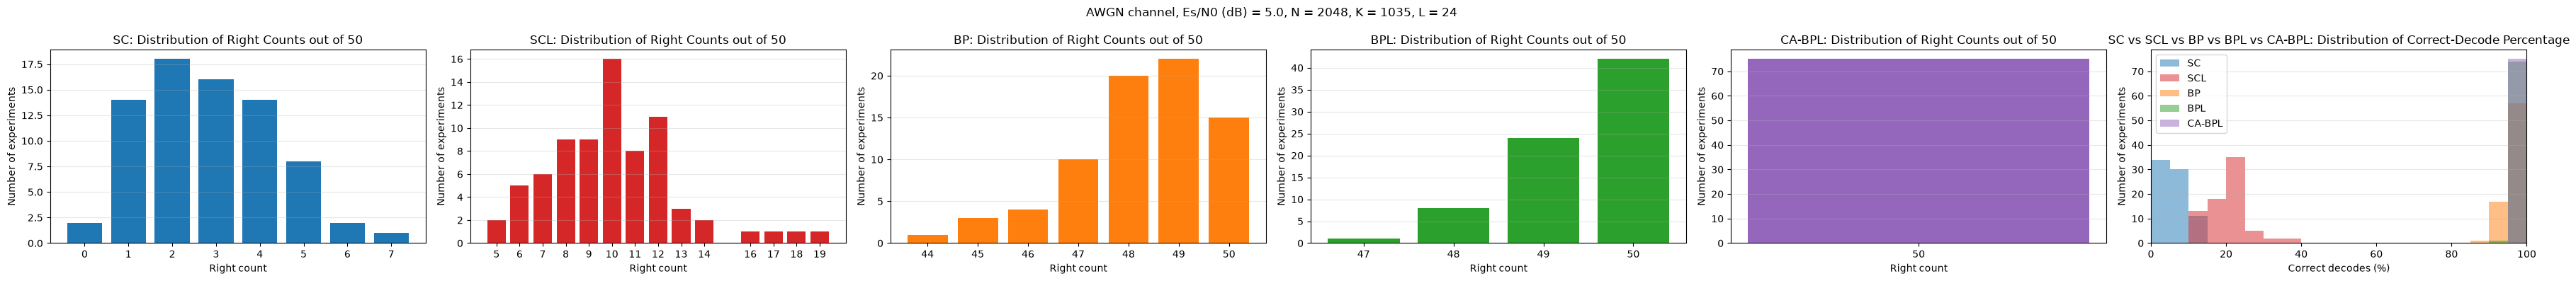

Saved figure and summary to results/AWGN_N1024_K523_20260722_010921.(png|txt)


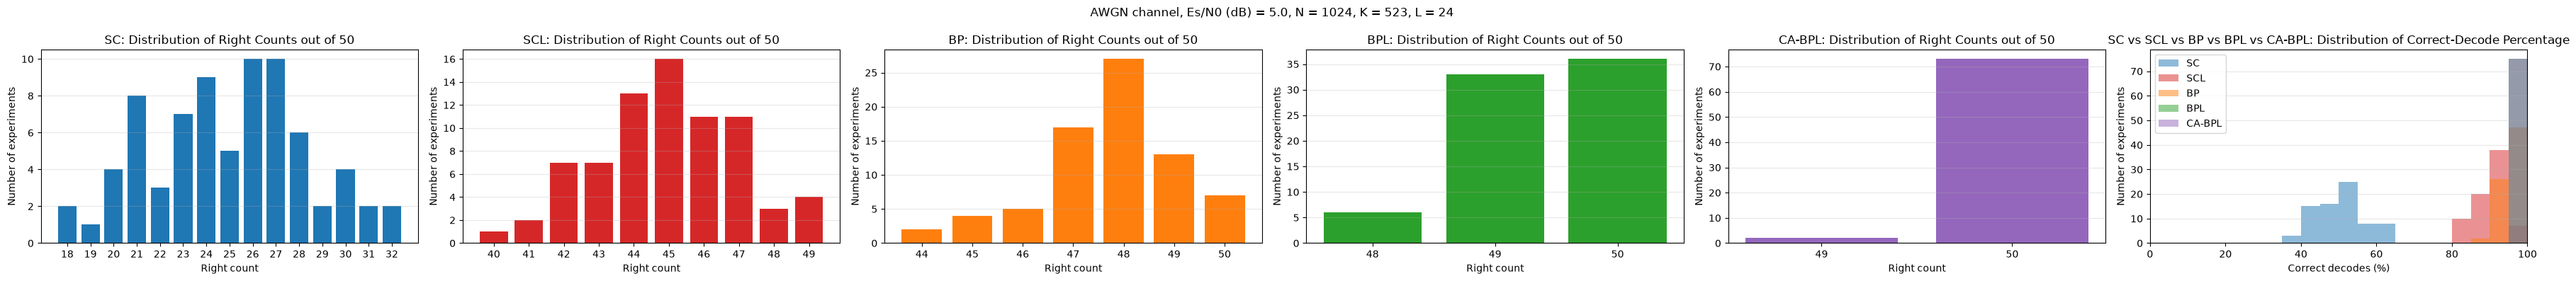

Saved figure and summary to results/AWGN_N512_K267_20260722_014144.(png|txt)


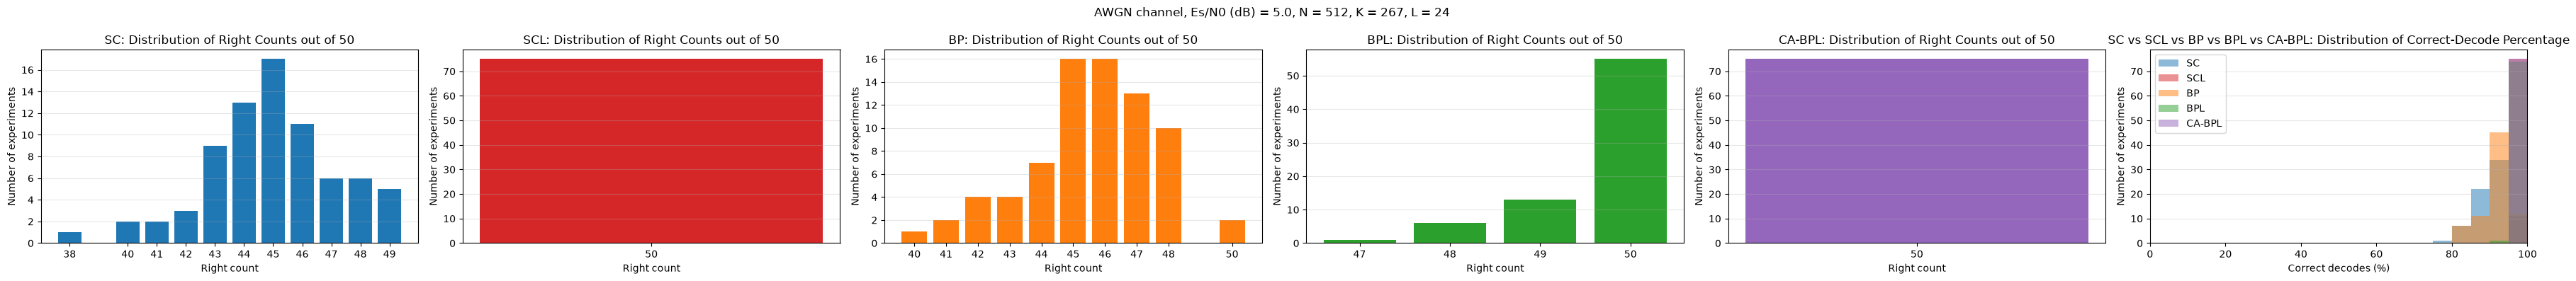

In [ ]:
import os

import matplotlib.pyplot as plt
from collections import Counter

colors = {"SC": "tab:blue", "SCL": "tab:red", "BP": "tab:orange", "BPL": "tab:green", "CA-BPL": "tab:purple"}

RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)

#*one figure per swept (N, K) config in `all_runs`, so every run from the loop above
#*gets its own saved figure instead of only the last one
for run in all_runs:
    #*one panel per decoder plus the shared overlay, so adding a decoder to `decoders`
    #*above widens this figure without any other edit here
    fig, axes = plt.subplots(1, len(run["results"]) + 1, figsize=(6 * (len(run["results"]) + 1), 4))
    fig.suptitle(f"{run['CHANNEL']} channel, {run['config']['param_name']} = {run['config']['param']}, "
                 f"N = {run['N']}, K = {run['K']}, L = {run['N_GRAPHS']}")

    for ax, (name, result) in zip(axes, run["results"].items()):
        distribution = Counter(result["right_counts"])
        x = sorted(distribution.keys())
        y = [distribution[count] for count in x]

        ax.bar(x, y, width=0.8, color=colors[name])
        ax.set_xlabel("Right count")
        ax.set_ylabel("Number of experiments")
        ax.set_title(f"{name}: Distribution of Right Counts out of {run['SAMPLES']}")
        ax.set_xticks(x)
        ax.grid(axis="y", alpha=0.3)

    #*every decoder now sees the same SAMPLES denominator, so the percentages are directly
    #*comparable; the fixed range keeps every bin inside [0, 100] so bars are never cropped
    overlay = axes[-1]
    for name, result in run["results"].items():
        pct = [count / run["SAMPLES"] * 100 for count in result["right_counts"]]
        overlay.hist(pct, bins=20, range=(0, 100), color=colors[name], alpha=0.5, label=name)

    overlay.set_xlabel("Correct decodes (%)")
    overlay.set_ylabel("Number of experiments")
    overlay.set_title(" vs ".join(run["results"]) + ": Distribution of Correct-Decode Percentage")
    overlay.set_xlim(0, 100)
    overlay.grid(axis="y", alpha=0.3)
    overlay.legend()

    plt.tight_layout()

    #*reuse the run_tag from the experiment cell so this figure's filename matches
    #*that run's saved .json/raw-data and .txt summary
    run_tag = run["run_tag"]
    fig.savefig(os.path.join(RESULTS_DIR, f"{run_tag}.png"), dpi=150, bbox_inches="tight")
    with open(os.path.join(RESULTS_DIR, f"{run_tag}.txt"), "w") as f:
        f.write("\n".join(run["summary_lines"]) + "\n")
    print(f"Saved figure and summary to {RESULTS_DIR}/{run_tag}.(png|txt)")

    plt.show()

Saved 6 subplot images and summary to results/AWGN_N2048_K1035_20260722_002308_*


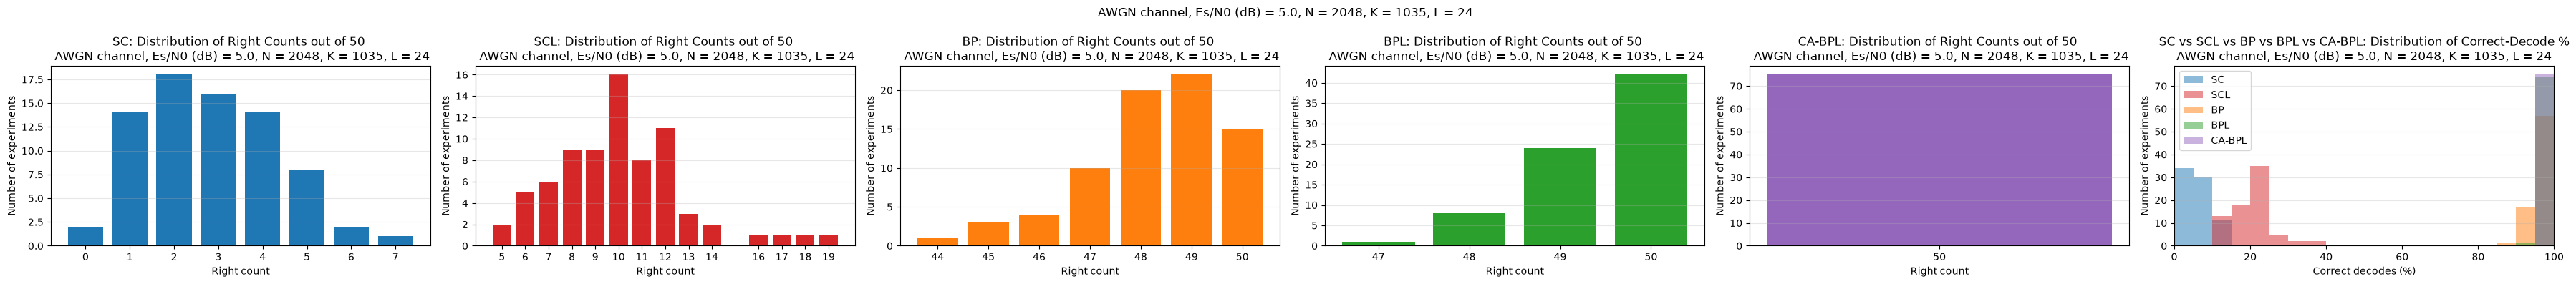

Saved 6 subplot images and summary to results/AWGN_N1024_K523_20260722_010921_*


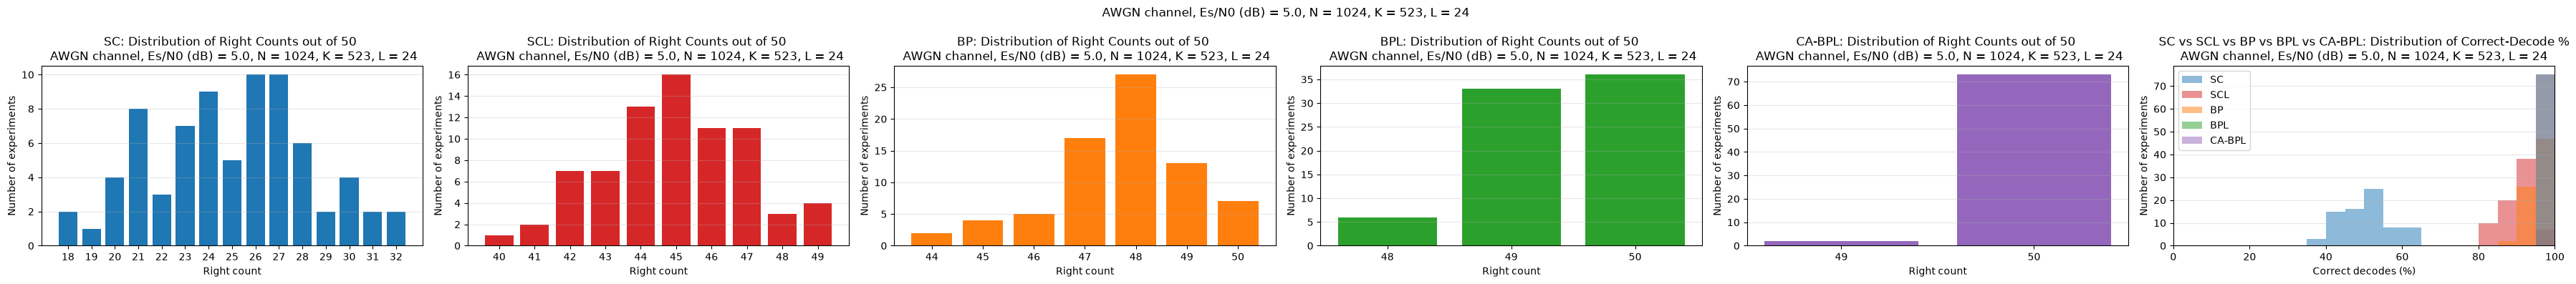

Saved 6 subplot images and summary to results/AWGN_N512_K267_20260722_014144_*


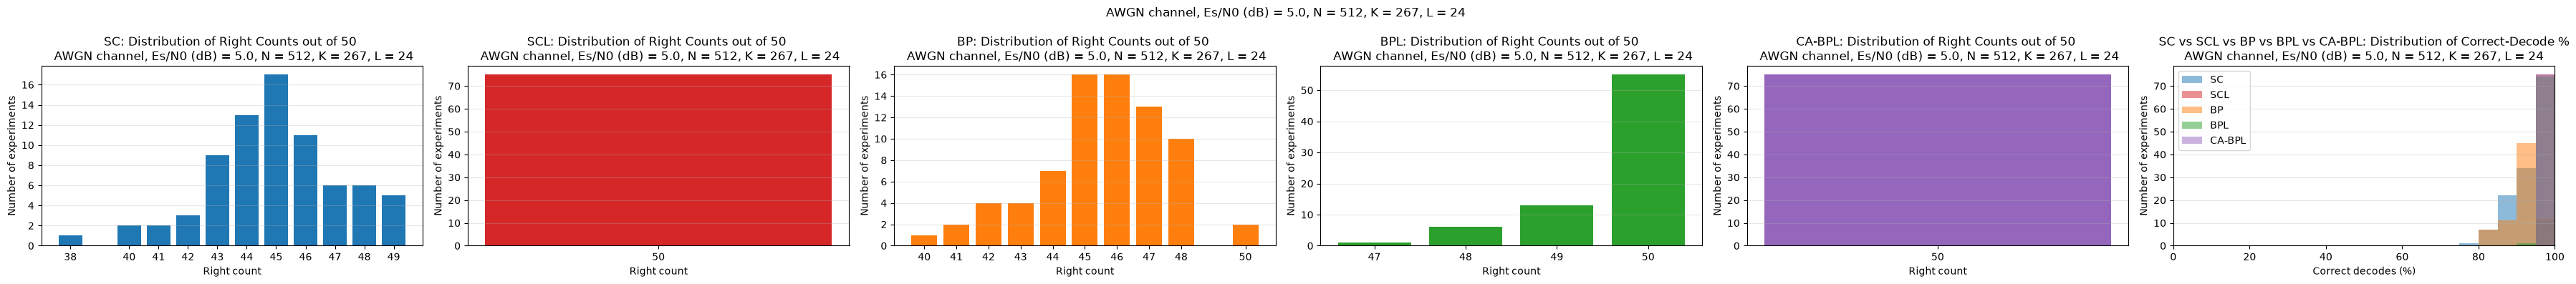

In [ ]:
import os

import matplotlib.pyplot as plt
from collections import Counter

colors = {"SC": "tab:blue", "SCL": "tab:red", "BP": "tab:orange", "BPL": "tab:green", "CA-BPL": "tab:purple"}

RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)

#*one figure (saved per-panel) per swept (N, K) config in `all_runs`, so every run from
#*the experiment loop gets its own saved subplot images instead of only the last one
for run in all_runs:
    #*one panel per decoder plus the shared overlay, so adding a decoder to `decoders`
    #*above widens this figure without any other edit here
    fig, axes = plt.subplots(1, len(run["results"]) + 1, figsize=(6 * (len(run["results"]) + 1), 4))
    fig.suptitle(f"{run['CHANNEL']} channel, {run['config']['param_name']} = {run['config']['param']}, "
                 f"N = {run['N']}, K = {run['K']}, L = {run['N_GRAPHS']}")

    for ax, (name, result) in zip(axes, run["results"].items()):
        distribution = Counter(result["right_counts"])
        x = sorted(distribution.keys())
        y = [distribution[count] for count in x]

        ax.bar(x, y, width=0.8, color=colors[name])
        ax.set_xlabel("Right count")
        ax.set_ylabel("Number of experiments")
        ax.set_title(f"{name}: Distribution of Right Counts out of {run['SAMPLES']} \n "
                     f"{run['CHANNEL']} channel, {run['config']['param_name']} = {run['config']['param']}, "
                     f"N = {run['N']}, K = {run['K']}, L = {run['N_GRAPHS']}")
        ax.set_xticks(x)
        ax.grid(axis="y", alpha=0.3)

    #*every decoder now sees the same SAMPLES denominator, so the percentages are directly
    #*comparable; the fixed range keeps every bin inside [0, 100] so bars are never cropped
    overlay = axes[-1]
    for name, result in run["results"].items():
        pct = [count / run["SAMPLES"] * 100 for count in result["right_counts"]]
        overlay.hist(pct, bins=20, range=(0, 100), color=colors[name], alpha=0.5, label=name)

    overlay.set_xlabel("Correct decodes (%)")
    overlay.set_ylabel("Number of experiments")
    overlay.set_title(f" vs ".join(run["results"]) + f": Distribution of Correct-Decode %\n"
                       f"{run['CHANNEL']} channel, {run['config']['param_name']} = {run['config']['param']}, "
                       f"N = {run['N']}, K = {run['K']}, L = {run['N_GRAPHS']}")
    overlay.set_xlim(0, 100)
    overlay.grid(axis="y", alpha=0.3)
    overlay.legend()

    plt.tight_layout()

    #*reuse the run_tag from the experiment cell so these per-panel images' filenames
    #*match that run's saved .json/raw-data and .txt summary
    run_tag = run["run_tag"]

    #*axes are [one panel per decoder, in `run["results"]` order] + [the overlay panel]
    #*force a layout pass so get_tightbbox() reflects final (post tight_layout) positions
    fig.canvas.draw()

    panel_names = list(run["results"].keys()) + ["overlay"]
    for ax, name in zip(axes, panel_names):
        #*get_tightbbox includes tick labels/axis labels/title, not just the bare axes box
        extent = ax.get_tightbbox(fig.canvas.get_renderer()).transformed(fig.dpi_scale_trans.inverted())

        #*pad uniformly, then nudge if the crop still leans the wrong way
        #*(dx > 0 moves right, dy > 0 moves up; tweak per-panel if needed)
        extent = extent.padded(0.15).translated(0.0, 0.0)

        fig.savefig(os.path.join(RESULTS_DIR, f"{run_tag}_{name}.png"), dpi=150, bbox_inches=extent)

    with open(os.path.join(RESULTS_DIR, f"{run_tag}.txt"), "w") as f:
        f.write("\n".join(run["summary_lines"]) + "\n")
    print(f"Saved {len(panel_names)} subplot images and summary to {RESULTS_DIR}/{run_tag}_*")

    plt.show()

In [ ]:
# Sanity: L=1 SCL must reproduce sc_decode_llr when both see the same
# finite-LLR input. SCL clips +-inf to +-30 internally to keep the path
# metric finite; SC uses raw LLRs by default, so we clip its input here too.
for _ in range(20):
    _u = np.random.randint(0, 2, size=K).astype(np.uint8)
    _llrs = channel.transmit(encoder.encode(_u))
    _llrs_clipped = np.where(_llrs == np.inf, 30.0, _llrs)
    _llrs_clipped = np.where(_llrs_clipped == -np.inf, -30.0, _llrs_clipped)
    _sc_full = sc_decode_llr(frozen_set, _llrs_clipped)
    _sc_info = np.array([int(_sc_full[i]) for i in range(_sc_full.size) if i not in frozen_set], dtype=np.uint8)
    _scl_info, _ = scl_decode(frozen_set, _llrs, L=1, use_gpu=False)
    assert np.array_equal(_sc_info, _scl_info), f"L=1 SCL diverges from SC:\n SC={_sc_info}\nSCL={_scl_info}"
print("SCL(L=1) == SC on 20 random words (clipped LLRs): OK")

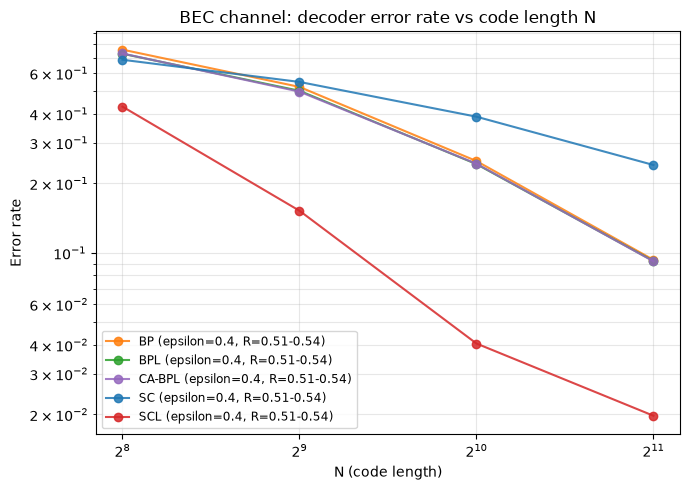

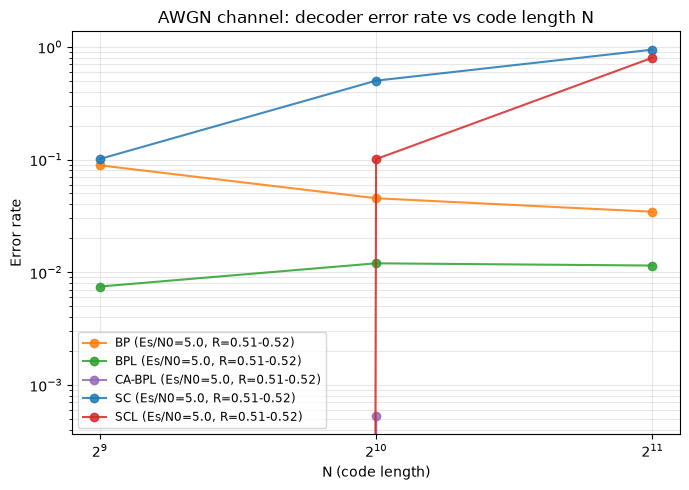

In [2]:
import glob
import json

import matplotlib.pyplot as plt

colors = {"SC": "tab:blue", "SCL": "tab:red", "BP": "tab:orange", "BPL": "tab:green", "CA-BPL": "tab:purple"}
PARAM_LABEL = {"BEC": "epsilon", "AWGN": "Es/N0"}

#*runs[channel][(channel_param, decoder)] = sorted list of (N, error_rate, K) points
runs: dict = {"BEC": {}, "AWGN": {}}

for path in sorted(glob.glob("results/*.json")):
    with open(path) as f:
        data = json.load(f)

    channel = data["channel"]
    if channel not in runs:
        continue  #*only BEC/AWGN are plotted

    for name, r in data["results"].items():
        total_words = data["iterations"] * data["samples"]
        error_rate = 1 - sum(r["right_counts"]) / total_words  #*block/word error rate

        key = (data["channel_param"], name)
        runs[channel].setdefault(key, []).append((data["N"], error_rate, data["K"]))

for channel, series in runs.items():
    if not series:
        print(f"No {channel} results found in results/ yet, skipping its plot.")
        continue

    fig, ax = plt.subplots(figsize=(7, 5))
    for (param, name), points in sorted(series.items()):
        points.sort(key=lambda p: p[0])
        Ns, ys, Ks = zip(*points)
        rates = [k / n for n, k in zip(Ns, Ks)]
        rate_note = f", R~{min(rates):.2f}" if max(rates) - min(rates) < 0.01 else f", R={min(rates):.2f}-{max(rates):.2f}"
        marker = "o" if len(points) == 1 else "o-"
        ax.plot(Ns, ys, marker, color=colors[name],
                 label=f"{name} ({PARAM_LABEL[channel]}={param}{rate_note})", alpha=0.85)

    ax.set_xlabel("N (code length)")
    ax.set_ylabel("Error rate")
    ax.set_xscale("log", base=2)
    ax.set_yscale("log")
    ax.set_title(f"{channel} channel: decoder error rate vs code length N")
    ax.grid(True, which="both", alpha=0.3)
    ax.legend(fontsize="small")
    plt.tight_layout()
    plt.show()


/home/inb0/Documents/CodeTheory/PolarCodes/src/core/scl.py:45: RuntimeWarning: invalid value encountered in add
  out = (1.0 - 2.0 * u) * a + b


SC      : median=  97.71 ms  mean= 101.63 ms  std= 16.31 ms  min=  90.91 ms  max= 165.24 ms
SCL     : median= 111.70 ms  mean= 112.37 ms  std=  3.82 ms  min= 107.01 ms  max= 124.62 ms
BP      : median= 216.14 ms  mean= 257.36 ms  std=116.44 ms  min= 168.27 ms  max= 581.24 ms
BPL     : median= 328.07 ms  mean= 371.64 ms  std=122.03 ms  min= 264.44 ms  max= 717.05 ms
CA-BPL  : median= 642.40 ms  mean= 662.33 ms  std= 57.82 ms  min= 568.95 ms  max= 879.57 ms
Saved figure and summary to results/timing_BEC_N2048_K1035_20260721_225224.(png|txt)



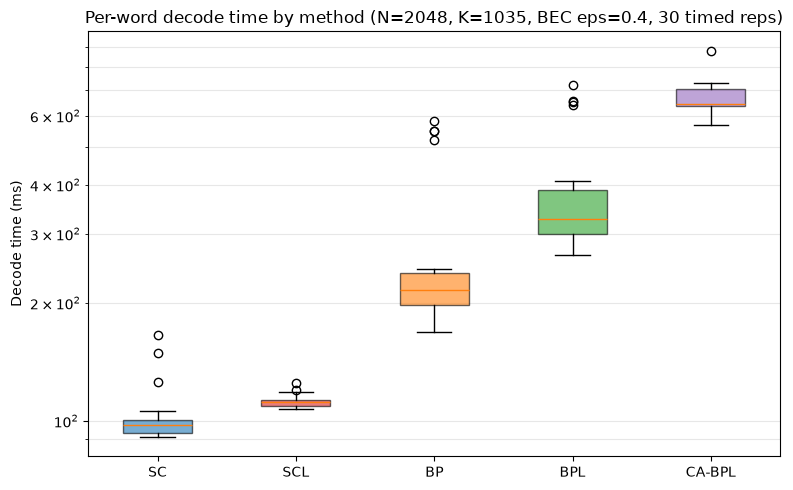

/home/inb0/Documents/CodeTheory/PolarCodes/src/core/scl.py:45: RuntimeWarning: invalid value encountered in add
  out = (1.0 - 2.0 * u) * a + b


SC      : median=  32.69 ms  mean=  33.53 ms  std=  4.07 ms  min=  29.55 ms  max=  47.30 ms
SCL     : median=  30.73 ms  mean=  30.63 ms  std=  1.76 ms  min=  28.30 ms  max=  37.11 ms
BP      : median=  45.78 ms  mean=  43.59 ms  std= 17.15 ms  min=  19.43 ms  max=  85.76 ms
BPL     : median= 333.20 ms  mean= 264.24 ms  std=137.46 ms  min=  85.20 ms  max= 469.75 ms
CA-BPL  : median= 345.39 ms  mean= 348.26 ms  std= 17.61 ms  min= 326.71 ms  max= 393.33 ms
Saved figure and summary to results/timing_BEC_N512_K267_20260721_225248.(png|txt)



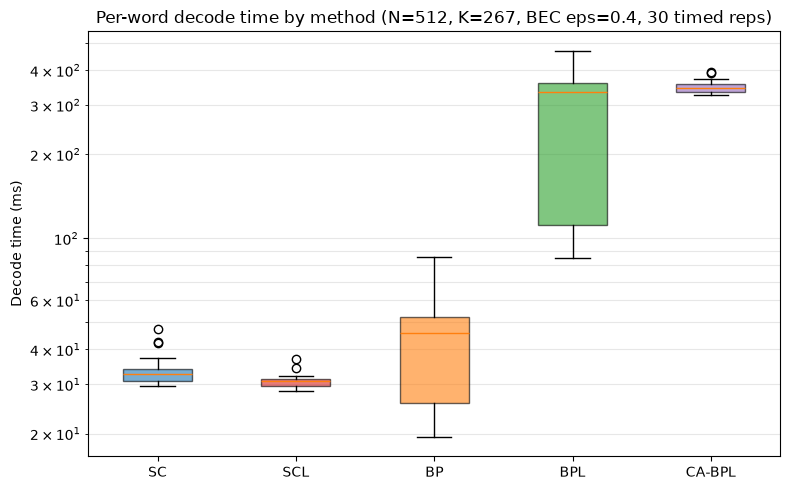

In [41]:
import os
import time
from datetime import datetime

import cupy as cp
import matplotlib.pyplot as plt
import numpy as np

from src.channels import BECChannel
from src.core import (
    PolarCode, PolarEncoder, bec_frozen_set,
    sc_decode_llr, scl_decode, bp_decode, bpl_decode,
)
from src.core.crc.crc import CRC

CHANNEL_PARAM = 0.4  #*same operating point already validated for correctness/difficulty earlier
L_SCL, N_GRAPHS, ITER_CAP = 8, 24, 40
REPS, WARMUP = 30, 3  #*timed / untimed-first trials per decoder

RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)
colors = {"SC": "tab:blue", "SCL": "tab:red", "BP": "tab:orange", "BPL": "tab:green", "CA-BPL": "tab:purple"}

def _sync():
    """cupy dispatches kernels async; without this, GPU decoders would only time
    kernel *launch*, not completion."""
    cp.cuda.Stream.null.synchronize()

for N, K in [(2048, 1035), (512, 267)]:
    frozen_set = bec_frozen_set(N, K, CHANNEL_PARAM)
    encoder = PolarEncoder(PolarCode(N, K, frozen_set))
    channel = BECChannel(CHANNEL_PARAM)
    crc = CRC("CRC11", K=K)
    M = K - crc.R

    decoders_timed = {
        "SC":     (lambda llrs, fs=frozen_set: sc_decode_llr(fs, llrs), False),
        "SCL":    (lambda llrs, fs=frozen_set: scl_decode(fs, llrs, L=L_SCL, use_gpu=False), False),
        "BP":     (lambda llrs, fs=frozen_set: bp_decode(fs, llrs, None, ITER_CAP, parallel=True), False),
        "BPL":    (lambda llrs, fs=frozen_set: bpl_decode(fs, llrs, N_GRAPHS, ITER_CAP, use_gpu=True), True),
        "CA-BPL": (lambda llrs, fs=frozen_set, c=crc: bpl_decode(fs, llrs, N_GRAPHS, ITER_CAP, ca=True, crc=c, use_gpu=True), True),
    }

    #*build the shared trial pool BEFORE timing anything, so every decoder sees the identical
    #*sequence of channel draws and the timed region contains only the decode call itself
    np.random.seed(0)
    trials = []
    for _ in range(WARMUP + REPS):
        u_msg = np.random.randint(0, 2, size=M).astype(np.uint8)
        u = np.array(crc.encode(u_msg), dtype=np.uint8)
        trials.append(channel.transmit(encoder.encode(u)))

    timings = {name: [] for name in decoders_timed}
    summary_lines = [f"BEC eps={CHANNEL_PARAM}, N={N}, K={K}, {REPS} timed reps (after {WARMUP} warm-up)"]
    for name, (decode_fn, uses_gpu) in decoders_timed.items():
        for i, llrs in enumerate(trials):
            if uses_gpu:
                _sync()
            t0 = time.perf_counter()
            decode_fn(llrs)
            if uses_gpu:
                _sync()
            t1 = time.perf_counter()
            if i >= WARMUP:
                timings[name].append(t1 - t0)
        ms = np.array(timings[name]) * 1e3
        line = (f"{name:8s}: median={np.median(ms):7.2f} ms  mean={np.mean(ms):7.2f} ms  "
                f"std={np.std(ms):6.2f} ms  min={np.min(ms):7.2f} ms  max={np.max(ms):7.2f} ms")
        print(line)
        summary_lines.append(line)

    fig, ax = plt.subplots(figsize=(8, 5))
    names = list(timings.keys())
    box = ax.boxplot([np.array(timings[n]) * 1e3 for n in names], tick_labels=names, patch_artist=True)
    for patch, name in zip(box["boxes"], names):
        patch.set_facecolor(colors[name])
        patch.set_alpha(0.6)
    ax.set_ylabel("Decode time (ms)")
    ax.set_yscale("log")
    ax.set_title(f"Per-word decode time by method (N={N}, K={K}, BEC eps={CHANNEL_PARAM}, {REPS} timed reps)")
    ax.grid(axis="y", which="both", alpha=0.3)
    plt.tight_layout()

    run_tag = f"timing_BEC_N{N}_K{K}_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
    fig.savefig(os.path.join(RESULTS_DIR, f"{run_tag}.png"), dpi=150, bbox_inches="tight")
    with open(os.path.join(RESULTS_DIR, f"{run_tag}.txt"), "w") as f:
        f.write("\n".join(summary_lines) + "\n")
    print(f"Saved figure and summary to {RESULTS_DIR}/{run_tag}.(png|txt)\n")

    plt.show()


In [6]:
np.float16(1.0 / 0.0)

ZeroDivisionError: float division by zero

In [ ]:
mat = np.array([[1, 2], [3, 4]])
mat = np.zeros([4, 5])
mat
arr1 = np.array([0, 1, 0])
arr2 = np.array([0, 1, 1])
for u_i, i in enumerate(arr2):
    print(u_i)
(arr1 == arr2).all()

In [ ]:
graph = [[["t", i], ["b", 8 - i]] for i in range(8)]
graph[0]

[['t', 0], ['b', 8]]

In [ ]:
u = [1, 0, 0, 0, 1, 1, 0, 1]
frozen_scratch = bec_frozen_set(16, 8, 0.5)
codeword_scratch = PolarEncoder(PolarCode(16, 8, frozen_scratch)).encode(u)
llrs_scratch = BECChannel(0.5).transmit(codeword_scratch, mode='llrs') #*Log LRs
bp_estimate, bp_ok = bp_decode(frozen_scratch, llrs_scratch, None, 200, True) #*already excludes frozen positions
bpl_estimate, bpl_ok = bpl_decode(frozen_scratch, llrs_scratch, 24, 200, use_gpu=False)
print("BP :", bp_estimate, bp_ok)
print("BPL:", bpl_estimate, bpl_ok)

In [2]:
TAPS = (11, 10, 9, 5, 0) #*non-zero positions of the poly
G = sum(1 << i for i in TAPS)
G

3617